#### Imports and Setups


In [ ]:
from typing import TypedDict
from langgraph_utils import console
from langgraph.graph import StateGraph, START, END

#### State

In [3]:
class UnitState(TypedDict):
    initial_unit: str
    final_unit: str
    intial_value: float
    final_value: float
    conversion_status: str

#### Node Functions

In [4]:
# unit converter
def unit_converter(state: UnitState) -> UnitState:
    if state["initial_unit"] == "kms" and state["final_unit"] == "miles":
        state["final_value"] = round(state["intial_value"] * 1.61, 2)

    elif state["initial_unit"] == "miles" and state["final_unit"] == "kms":
        state["final_value"] = round(state["intial_value"] / 1.61, 2)

    return state

In [5]:
# update status
def update_status(state: UnitState) -> UnitState:
    if "final_value" in state:
        state["conversion_status"] = "Success"
    else:
        state["conversion_status"] = "Failure"

    return state

#### Init Graph

In [6]:
graph = StateGraph(UnitState)

#### Add Nodes

In [7]:
graph.add_node("unit_converter", unit_converter)
graph.add_node("update_status", update_status)

#### Add Edges

In [8]:
graph.add_edge(START, "unit_converter")
graph.add_edge("unit_converter", "update_status")
graph.add_edge("update_status", END)

#### Compilation


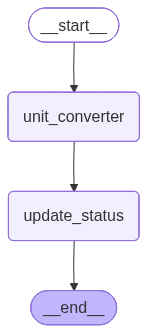

In [9]:
workflow = graph.compile()
workflow

#### Execution


In [10]:
final_state = workflow.invoke(
    {
        "initial_unit": "kms",
        "final_unit": "miles",
        "intial_value": 150,
    }
)
console.print_json(data=final_state)

{
  "initial_unit": "kms",
  "final_unit": "miles",
  "intial_value": 150,
  "final_value": 241.5,
  "conversion_status": "Success"
}


In [11]:
final_state = workflow.invoke(
    {
        "initial_unit": "miles",
        "final_unit": "kms",
        "intial_value": 150,
    }
)
console.print_json(data=final_state)

{
  "initial_unit": "miles",
  "final_unit": "kms",
  "intial_value": 150,
  "final_value": 93.17,
  "conversion_status": "Success"
}


In [12]:
final_state = workflow.invoke(
    {
        "initial_unit": "miles",
        "final_unit": "foot",
        "intial_value": 150,
    }
)
console.print_json(data=final_state)

{
  "initial_unit": "miles",
  "final_unit": "foot",
  "intial_value": 150,
  "conversion_status": "Failure"
}
